# Stage 1 â€” Hammer Impact SEMM

Dedicated notebook for Stage 1 of the thermoelastic stress expansion pipeline.

**What this notebook does:**
1. Loads 6 hammer-impact cases (camera IR + force sensor)
2. Detects impacts, crops & windows signals, computes H1 camera FRFs
3. Runs FEA solver for numerical stress FRFs at the same frequencies
4. Fuses camera + FEA via SEMM to produce the expanded stress FRF tensor
5. Provides comprehensive diagnostics at every step
6. Saves Stage 1 results independently (no Stage 2 required)

The saved output can be loaded by `transmissibility_expansion.ipynb` or `direct_psd_expansion.ipynb`.

In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

cwd = Path.cwd().resolve()
if cwd.name == 'dual_stage_base_pipeline':
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from dual_stage_base_pipeline.semm_thermoelastic_pipeline import (
        SEMMThermoelasticPipeline,
        PathsConfig,
        Stage1Config,
        Stage2Config,
        SEMMConfig,
    )
except ModuleNotFoundError:
    from semm_thermoelastic_pipeline import (
        SEMMThermoelasticPipeline,
        PathsConfig,
        Stage1Config,
        Stage2Config,
        SEMMConfig,
    )

In [3]:
# ======================== CONFIGURATION ========================
DATA_ROOT = Path(r'C:\Users\jasas\Work\Clanki\Clanek_2\data')
PIPE_DIR = Path(r'C:\Users\jasas\Work\Clanki\Clanek_2\thermoelastic-stress-expansion\dual_stage_base_pipeline')

# Stage-1 cases: HCC camera files + PKL force files (experiment_20260305_02 — best run)
stage1_cases = {
    "right_top": {
        "pkl_path": r"experiment_20260305_02/stage1_hammer/01_top_right.pkl",
        "hcc_path": r"experiment_20260305_02/stage1_camera/DefaultName_20260305T070842469/_20260305T070842469_20260305T070842902.hcc",
    },
    "center_top": {
        "pkl_path": r"experiment_20260305_02/stage1_hammer/02_top_center.pkl",
        "hcc_path": r"experiment_20260305_02/stage1_camera/DefaultName_20260305T070859161/_20260305T070859161_20260305T070859546.hcc",
    },
    "left_top": {
        "pkl_path": r"experiment_20260305_02/stage1_hammer/03_top_left.pkl",
        "hcc_path": r"experiment_20260305_02/stage1_camera/DefaultName_20260305T070915642/_20260305T070915642_20260305T070916035.hcc",
    },
    "right_middle": {
        "pkl_path": r"experiment_20260305_02/stage1_hammer/04_middle_right.pkl",
        "hcc_path": r"experiment_20260305_02/stage1_camera/DefaultName_20260305T070932285/_20260305T070932285_20260305T070932667.hcc",
    },
    "center_middle": {
        "pkl_path": r"experiment_20260305_02/stage1_hammer/05_middle_center.pkl",
        "hcc_path": r"experiment_20260305_02/stage1_camera/DefaultName_20260305T070948928/_20260305T070948928_20260305T070949324.hcc",
    },
    "left_middle": {
        "pkl_path": r"experiment_20260305_02/stage1_hammer/06_middle_left.pkl",
        "hcc_path": r"experiment_20260305_02/stage1_camera/DefaultName_20260305T071005391/_20260305T071005391_20260305T071005809.hcc",
    },
}

paths_cfg = PathsConfig(
    project_root=str(DATA_ROOT),
    crop_json=str(PIPE_DIR / 'configs/crop.json'),
    output_root=str(PIPE_DIR / 'outputs'),
    stage1_run_root=str(PIPE_DIR / 'outputs/_stage1_numerical_runs'),
    stage1_cases=stage1_cases,
)

stage1_cfg = Stage1Config(
    f_min=50.0,
    f_max=300.0,
    n_segments=1,
    fs_ir_fallback=2000.0,
    # crop auto-loaded from crop.json
    reduce_factor=3,
    flip_vertical=False,
    flip_horizontal=False,
    enable_impact_sync_crop=True,
)

# Stage2Config + SEMMConfig needed by constructor but not used in this notebook
stage2_cfg = Stage2Config()
semm_cfg = SEMMConfig(
    f_semm_min=40.0,
    f_semm_max=300.0,
    semm_lines_per_chunk=1,
    log_every_n_chunks=5,
    semm_type='fully-extend-svd',
)

pipe = SEMMThermoelasticPipeline(
    paths=paths_cfg,
    stage1=stage1_cfg,
    stage2=stage2_cfg,
    semm=semm_cfg,
)

print(f'Project root: {DATA_ROOT}')
print(f'Output root:  {paths_cfg.output_root}')
print(f'Crop (auto-loaded): {pipe.stage1_cfg.crop}')

Project root: C:\Users\jasas\Work\Clanki\Clanek_2\Trigger_and_acquisition
Output root:  C:\Users\jasas\Work\Clanki\Clanek_2\Trigger_and_acquisition\dual_stage_base_pipeline\outputs
Crop (auto-loaded): {'row_start': 17, 'row_end': 121, 'col_start': 14, 'col_end': 118}


In [4]:
# ======================== RE-PICK CROP (OPTIONAL) ========================
# Run this cell to interactively pick a new crop. Saves to crop.json.
# SKIP this cell to keep the current crop.

%matplotlib qt
from fasthcc import read_hcc

# Grab the first HCC file from the configured cases
_hcc_path = list(pipe.paths.stage1_cases.values())[0]['hcc_path']
_imgs = read_hcc(str(pipe._resolve_path(_hcc_path)), calibrated=True)

pipe.pick_crop(_imgs, frame_index=0, save=True)
print('Crop saved:', pipe.stage1_cfg.crop)
del _imgs, _hcc_path
%matplotlib inline

Crop saved: {'row_start': 17, 'row_end': 121, 'col_start': 14, 'col_end': 118}


In [5]:
# ======================== BUILD CAMERA FRFs ========================
stage1_cam = pipe.build_hammer_stage1()

print(f"Cases:      {stage1_cam['case_labels']}")
print(f"Grid:       {stage1_cam['rows']} x {stage1_cam['cols']}")
print(f"Freq range: {stage1_cam['freq_target'][0]:.1f} - {stage1_cam['freq_target'][-1]:.1f} Hz")
print(f"Y_cam_all:  {stage1_cam['Y_cam_all'].shape}")

Cases:      ['right_top', 'center_top', 'left_top', 'right_middle', 'center_middle', 'left_middle']
Grid:       34 x 34
Freq range: 50.0 - 299.9 Hz
Y_cam_all:  (1229, 1156, 6)


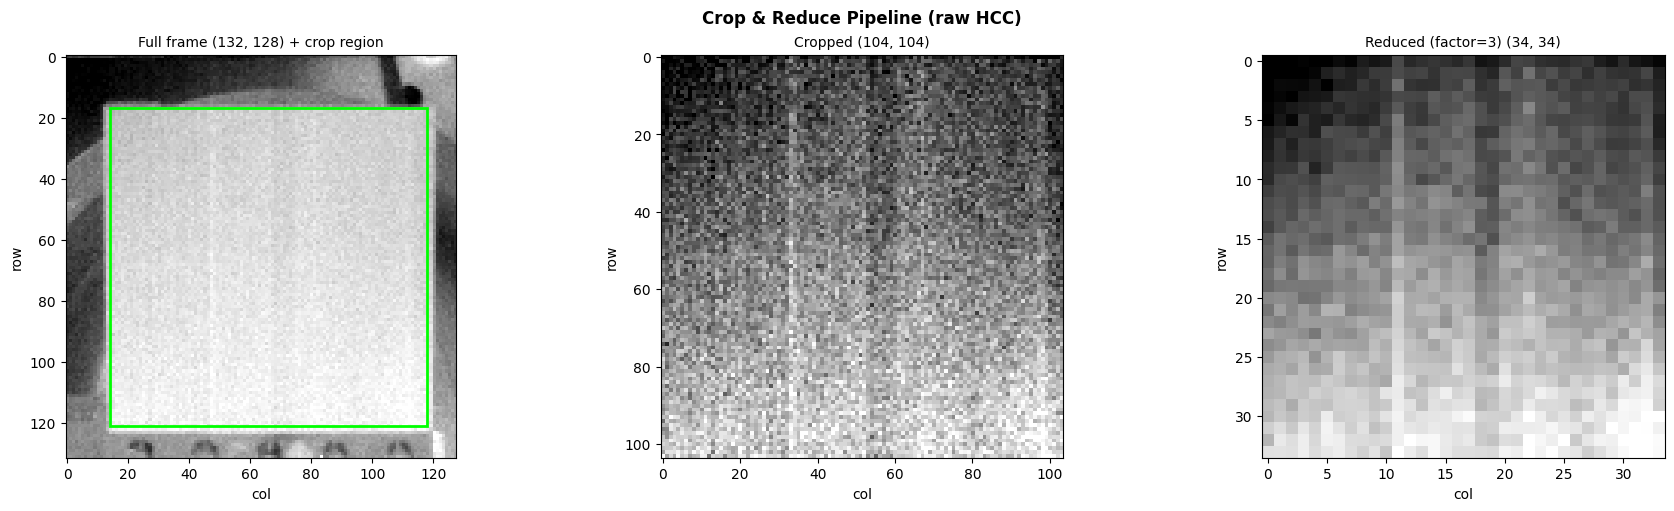

Crop:   {'row_start': 17, 'row_end': 121, 'col_start': 14, 'col_end': 118}
Full:   (132, 128)  ->  Cropped: (104, 104)  ->  Reduced: (34, 34)
FRF grid (rows x cols): 34 x 34


In [6]:
# ======================== CROP REGION VISUALIZATION ========================
from fasthcc import read_hcc
import matplotlib.patches as mpatches

# Load raw HCC frame (same source as pick_crop cell)
_hcc_dir = DATA_ROOT / 'experiment_20260305_02' / 'stage1_camera'
_hcc_folder = sorted(_hcc_dir.iterdir())[0]
_hcc_file = next(_hcc_folder.glob('*.hcc'))
images_full = read_hcc(str(_hcc_file), calibrated=True)

frame0 = images_full[0]
crop = pipe.stage1_cfg.crop

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Panel 1: full frame with crop rectangle
ax = axes[0]
vmin, vmax = np.percentile(frame0, [1, 99])
ax.imshow(frame0, cmap='gray', vmin=vmin, vmax=vmax, origin='upper')
if crop is not None:
    r0, r1 = crop['row_start'], crop['row_end']
    c0, c1 = crop['col_start'], crop['col_end']
    rect = mpatches.Rectangle((c0, r0), c1 - c0, r1 - r0,
                               linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.set_title(f'Full frame {frame0.shape} + crop region', fontsize=10)
else:
    ax.set_title(f'Full frame {frame0.shape} (no crop)', fontsize=10)
ax.set_xlabel('col')
ax.set_ylabel('row')

# Panel 2: cropped frame
cropped = pipe.crop_video(images_full[:1], crop)[0]
ax2 = axes[1]
vmin2, vmax2 = np.percentile(cropped, [1, 99])
ax2.imshow(cropped, cmap='gray', vmin=vmin2, vmax=vmax2, origin='upper')
ax2.set_title(f'Cropped {cropped.shape}', fontsize=10)
ax2.set_xlabel('col')
ax2.set_ylabel('row')

# Panel 3: reduced resolution (as used in FRFs)
reduced = pipe.reduce_resolution(cropped[np.newaxis], pipe.stage1_cfg.reduce_factor, mode='crop')[0]
ax3 = axes[2]
vmin3, vmax3 = np.percentile(reduced, [1, 99])
ax3.imshow(reduced, cmap='gray', vmin=vmin3, vmax=vmax3, origin='upper')
ax3.set_title(f'Reduced (factor={pipe.stage1_cfg.reduce_factor}) {reduced.shape}', fontsize=10)
ax3.set_xlabel('col')
ax3.set_ylabel('row')

fig.suptitle('Crop & Reduce Pipeline (raw HCC)', fontsize=12, fontweight='bold')
plt.show()

print(f'Crop:   {crop}')
print(f'Full:   {frame0.shape}  ->  Cropped: {cropped.shape}  ->  Reduced: {reduced.shape}')
print(f'FRF grid (rows x cols): {pipe.state["stage1"]["rows"]} x {pipe.state["stage1"]["cols"]}')

del images_full

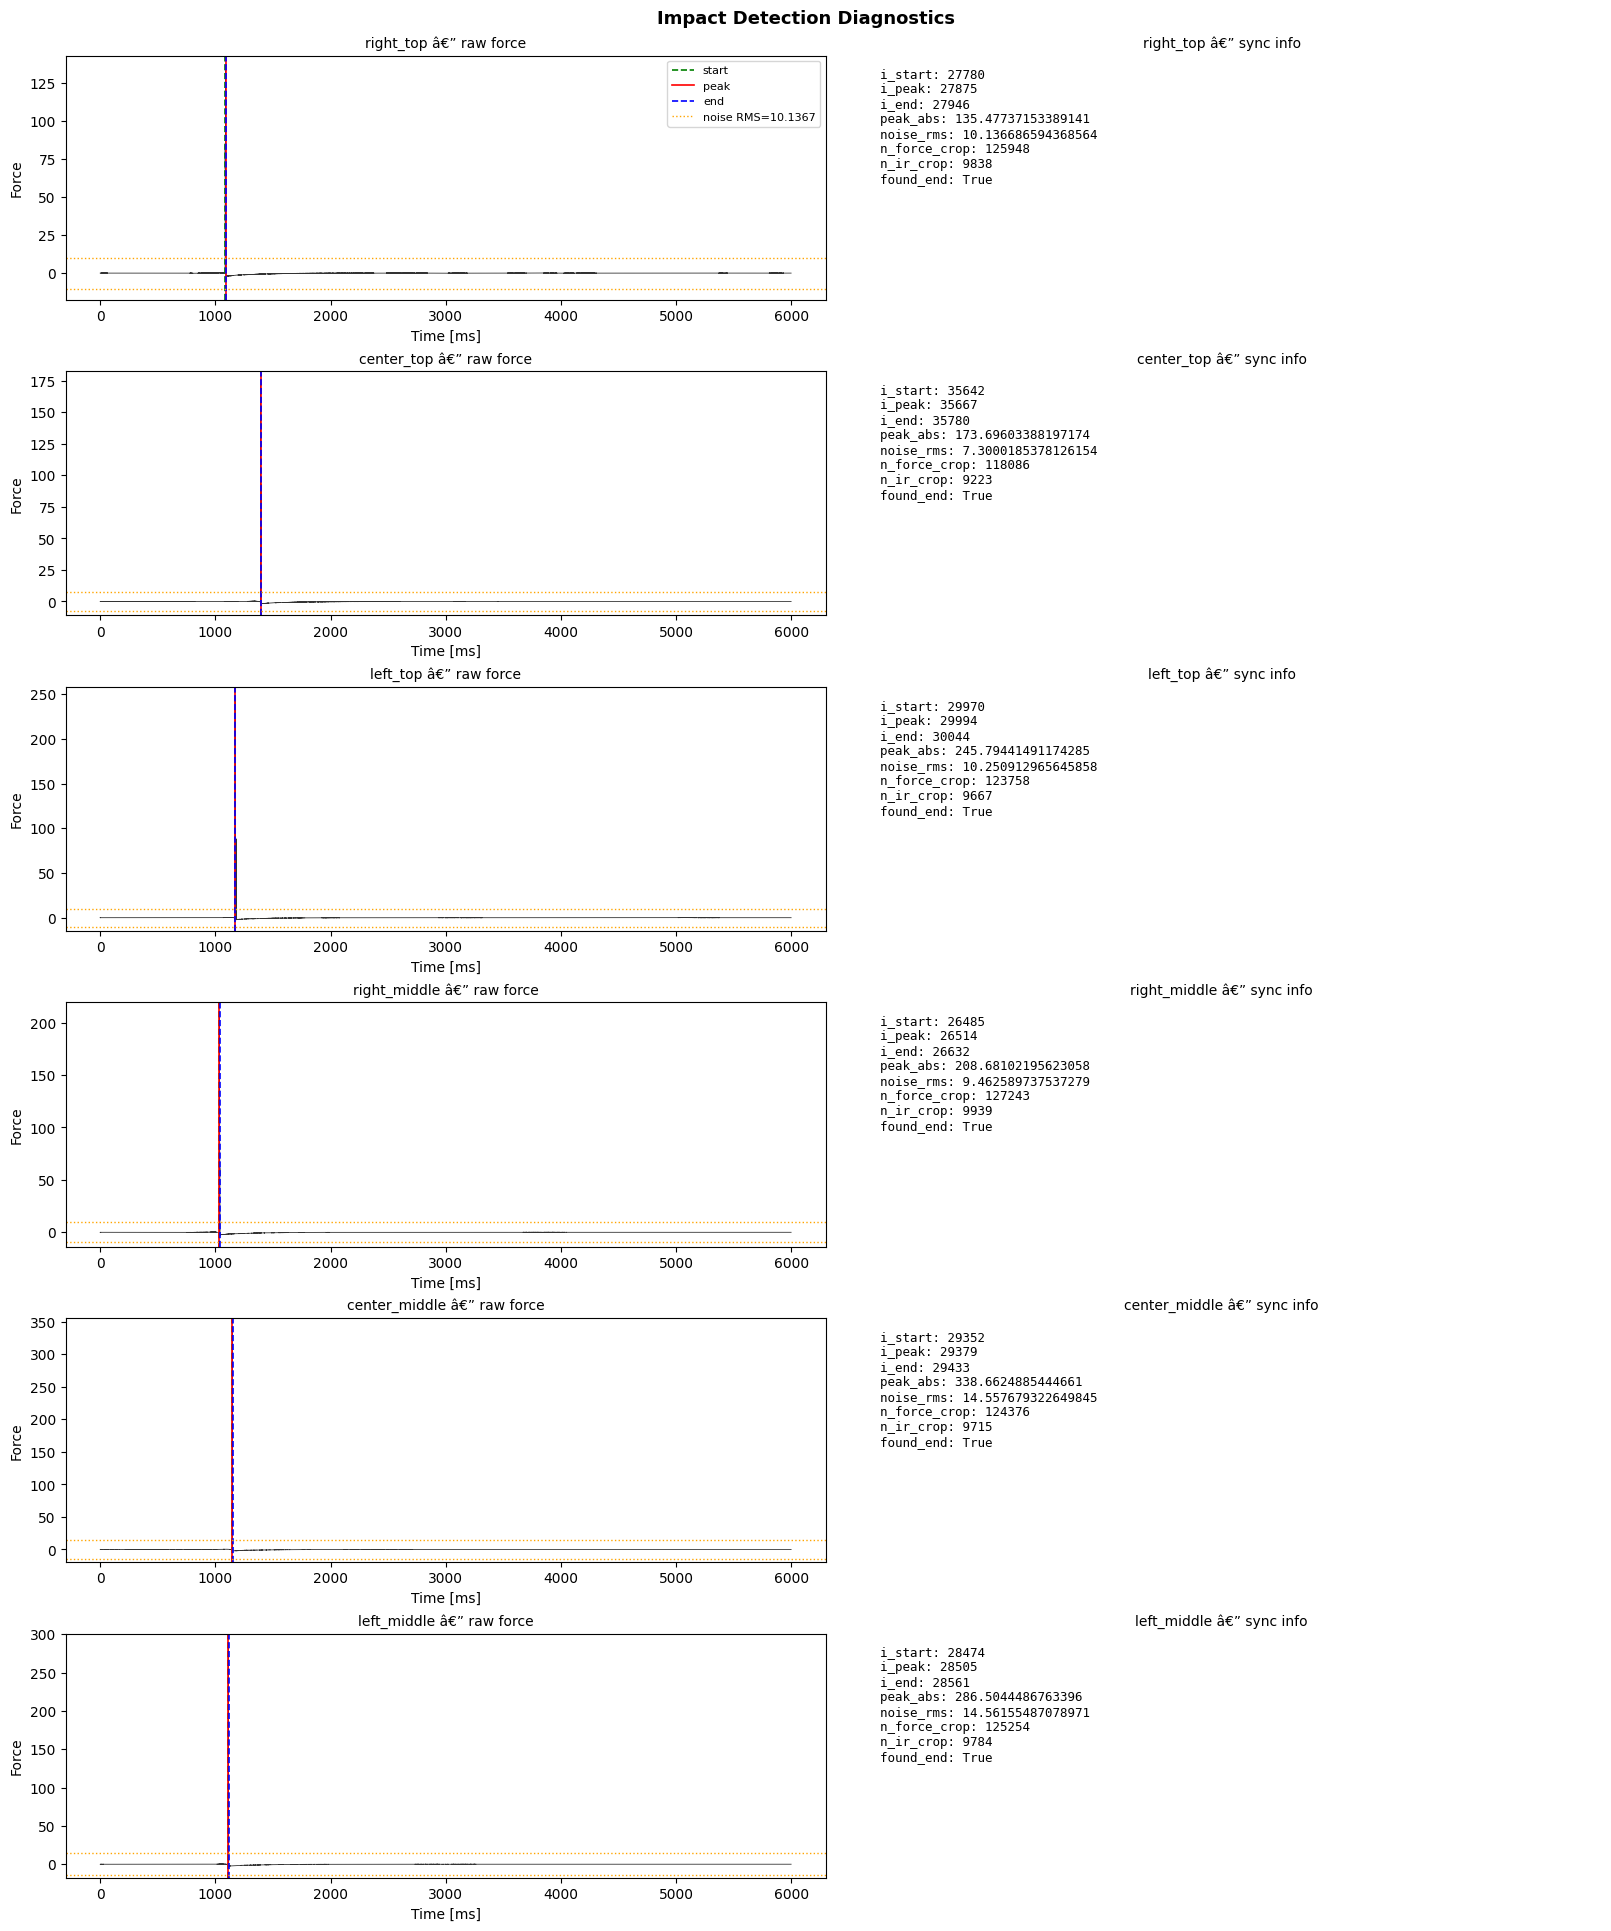

In [7]:
# ======================== IMPACT DETECTION DIAGNOSTICS ========================
import pickle

sync_info = pipe.state['stage1']['sync_info']
case_labels = pipe.state['stage1']['case_labels']
cases_dict = pipe.state['stage1']['cases']
cfg = pipe.stage1_cfg

n_cases = len(case_labels)
fig, axes = plt.subplots(n_cases, 2, figsize=(16, 3.2 * n_cases), constrained_layout=True)
if n_cases == 1:
    axes = axes[np.newaxis, :]

for k, label in enumerate(case_labels):
    si = sync_info[label]
    c = cases_dict[label]

    # Reload raw force to show before/after windowing
    pkl_path = pipe._resolve_path(c.get('pkl_path', c.get('hcc_path', '')))
    if pkl_path.suffix == '.pkl' and pkl_path.exists():
        force_raw, fs_force, _, _ = pipe.load_force_from_pkl(
            pkl_path,
            task_name=cfg.force_task_name,
            force_name=cfg.force_channel_name,
        )
    else:
        force_raw = np.zeros(100)
        fs_force = 1.0

    t_raw = np.arange(len(force_raw)) / fs_force

    # Left panel: raw force with impact bounds
    ax = axes[k, 0]
    ax.plot(t_raw * 1e3, force_raw, 'k-', lw=0.6, alpha=0.8)
    if 't_start_s' in si:
        ax.axvline(si['t_start_s'] * 1e3, color='g', ls='--', lw=1.2, label='start')
    if 't_peak_s' in si:
        ax.axvline(si['t_peak_s'] * 1e3, color='r', ls='-', lw=1.2, label='peak')
    if 't_end_s' in si:
        ax.axvline(si['t_end_s'] * 1e3, color='b', ls='--', lw=1.2, label='end')
    if 'noise_rms' in si:
        ax.axhline(si['noise_rms'], color='orange', ls=':', lw=1, label=f'noise RMS={si["noise_rms"]:.4f}')
        ax.axhline(-si['noise_rms'], color='orange', ls=':', lw=1)
    ax.set_title(f'{label} â€” raw force', fontsize=10)
    ax.set_xlabel('Time [ms]')
    ax.set_ylabel('Force')
    if k == 0:
        ax.legend(fontsize=8, loc='upper right')

    # Right panel: sync info summary
    ax2 = axes[k, 1]
    info_lines = []
    for key in ['i_start', 'i_peak', 'i_end', 'peak_abs', 'noise_rms',
                'n_force_crop', 'n_ir_crop', 'found_end']:
        if key in si:
            val = si[key]
            info_lines.append(f'{key}: {val}')
    ax2.text(0.05, 0.95, '\n'.join(info_lines), transform=ax2.transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace')
    ax2.set_title(f'{label} â€” sync info', fontsize=10)
    ax2.axis('off')

fig.suptitle('Impact Detection Diagnostics', fontsize=13, fontweight='bold')
plt.show()

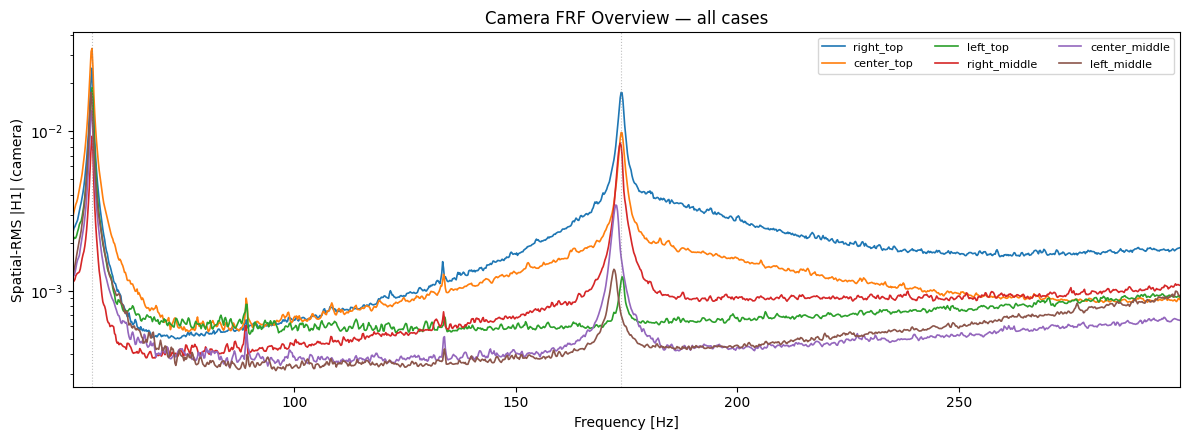


Detected resonance frequencies (2 peaks):
  Peak 1: 54.32 Hz  (RMS = 2.0641e-02)
  Peak 2: 173.74 Hz  (RMS = 8.8662e-03)


In [13]:
# ======================== CAMERA FRF OVERVIEW ========================
from scipy.signal import find_peaks

freq_target = np.asarray(pipe.state['stage1']['freq_target'], dtype=float)
Y_cam_all = np.asarray(pipe.state['stage1']['Y_cam_all'])
rows = int(pipe.state['stage1']['rows'])
cols = int(pipe.state['stage1']['cols'])
case_labels = pipe.state['stage1']['case_labels']

# Spatial-RMS of camera FRF magnitude for each case
fig, ax = plt.subplots(figsize=(12, 4.5))
for k, label in enumerate(case_labels):
    rms_k = np.sqrt(np.mean(np.abs(Y_cam_all[:, :, k]) ** 2, axis=1))
    ax.semilogy(freq_target, np.maximum(rms_k, 1e-30), label=label, lw=1.2)

# Detect peaks from average spatial-RMS across all cases
rms_avg = np.sqrt(np.mean(np.abs(Y_cam_all) ** 2, axis=(1, 2)))
peak_idx, peak_props = find_peaks(rms_avg, prominence=np.max(rms_avg) * 0.1, distance=20)
for pi in peak_idx:
    ax.axvline(freq_target[pi], color='gray', ls=':', lw=0.8, alpha=0.5)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Spatial-RMS |H1| (camera)')
ax.set_title('Camera FRF Overview — all cases')
ax.legend(fontsize=8, ncol=3)
ax.set_xlim(freq_target[0], freq_target[-1])
plt.tight_layout()
plt.show()

# Print detected resonances
print(f'\nDetected resonance frequencies ({len(peak_idx)} peaks):')
for i, pi in enumerate(peak_idx):
    print(f'  Peak {i+1}: {freq_target[pi]:.2f} Hz  (RMS = {rms_avg[pi]:.4e})')

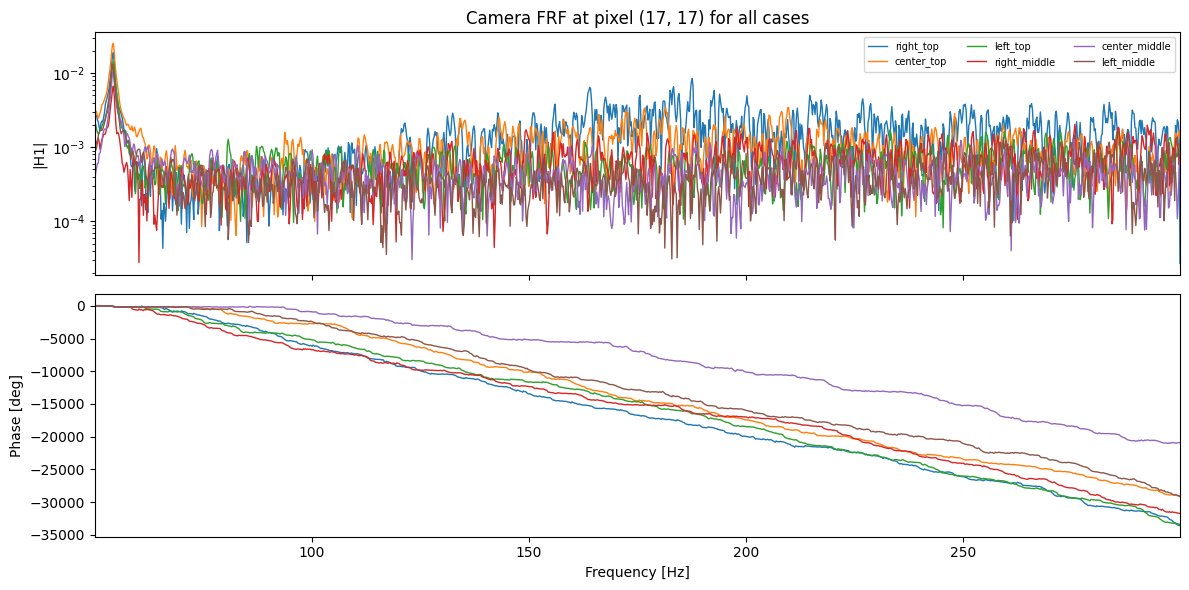

In [14]:
# ======================== CAMERA FRF AT SELECTED PIXEL ========================
# Center pixel, magnitude + phase across all 6 cases
r_sel, c_sel = rows // 2, cols // 2
pix_sel = r_sel * cols + c_sel

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for k, label in enumerate(case_labels):
    h = Y_cam_all[:, pix_sel, k]
    ax1.semilogy(freq_target, np.maximum(np.abs(h), 1e-30), label=label, lw=1)
    ax2.plot(freq_target, np.unwrap(np.angle(h)) * 180 / np.pi, lw=1)

ax1.set_ylabel('|H1|')
ax1.set_title(f'Camera FRF at pixel ({r_sel}, {c_sel}) for all cases')
ax1.legend(fontsize=7, ncol=3)
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Phase [deg]')
ax1.set_xlim(freq_target[0], freq_target[-1])
plt.tight_layout()
plt.show()

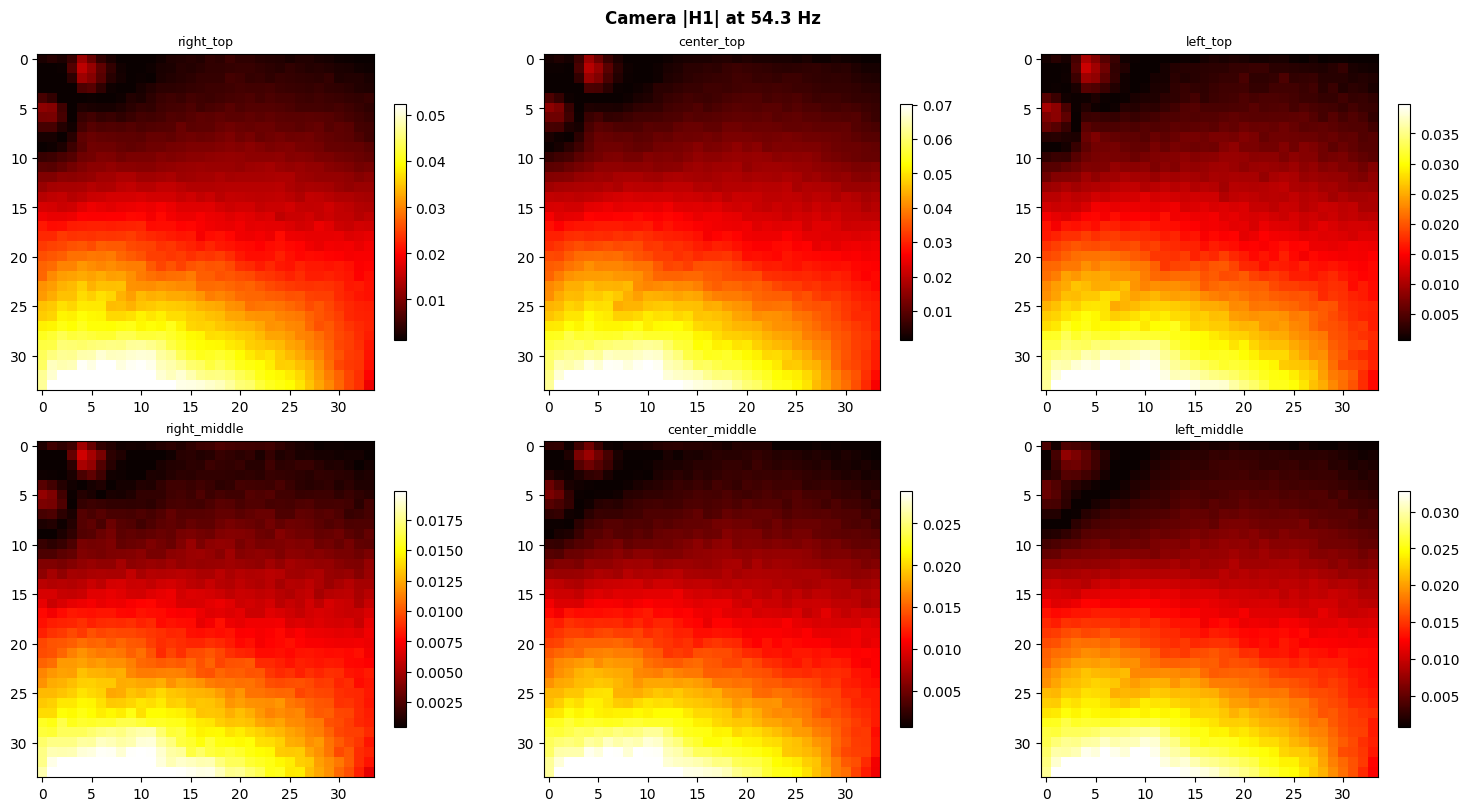

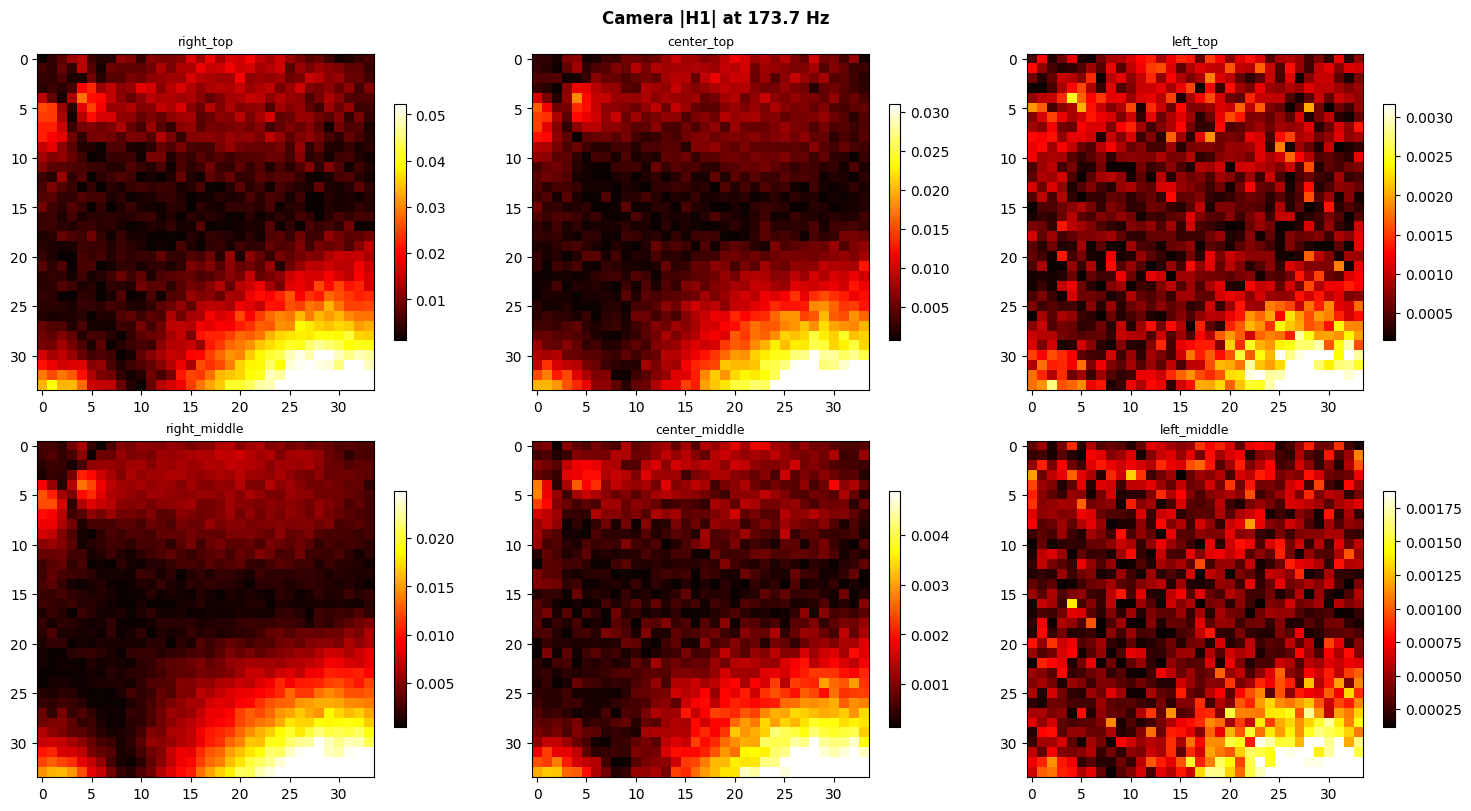

In [15]:
# ======================== CAMERA FRF SPATIAL MAPS AT PEAKS ========================
# For each detected peak: 2x3 grid of magnitude maps (6 cases)
n_show = min(len(peak_idx), 4)  # at most 4 peaks

for ip in range(n_show):
    fi = peak_idx[ip]
    f_hz = freq_target[fi]

    ncols_plot = min(n_cases, 3)
    nrows_plot = int(np.ceil(n_cases / ncols_plot))
    fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(5 * ncols_plot, 4 * nrows_plot),
                             constrained_layout=True)
    axes_flat = np.asarray(axes).flatten()

    for k, label in enumerate(case_labels):
        mag = np.abs(Y_cam_all[fi, :, k]).reshape(rows, cols)
        vmin, vmax = np.percentile(mag, [2, 98])
        im = axes_flat[k].imshow(mag, cmap='hot', vmin=vmin, vmax=vmax,
                                 aspect='equal', origin='upper')
        axes_flat[k].set_title(label, fontsize=9)
        plt.colorbar(im, ax=axes_flat[k], shrink=0.7)

    # Hide unused axes
    for j in range(n_cases, len(axes_flat)):
        axes_flat[j].axis('off')

    fig.suptitle(f'Camera |H1| at {f_hz:.1f} Hz', fontsize=12, fontweight='bold')
    plt.show()

In [16]:
# ======================== COHERENCE NOTE ========================
# With n_segments=1 (single FFT realization for impact data), coherence = 1.0
# everywhere by definition. This is expected and correct for impact testing
# where each measurement is a single transient.
#
# To compute meaningful coherence, re-run with n_segments > 1 (requires longer
# time records or accepting reduced frequency resolution). For impact testing,
# the quality is instead assessed via:
#   - Impact detection quality (Cell 4)
#   - Consistency across cases (Cells 5-6)
#   - SEMM update ratio (Cell 13)
print(f'n_segments = {stage1_cfg.n_segments}')
print('Coherence = 1.0 everywhere (single realization per case).')
print('Quality is assessed via impact detection + cross-case consistency + SEMM update ratio.')

n_segments = 1
Coherence = 1.0 everywhere (single realization per case).
Quality is assessed via impact detection + cross-case consistency + SEMM update ratio.


In [17]:
# ======================== RUN FEA + SEMM ========================
stage1 = pipe.run_stage1_numerical_and_semm()

print(f"\nY_SEMM:  {stage1['Y_SEMM'].shape}")
print(f"Y_final2: {stage1['Y_final2'].shape}")
print(f"freqs:    {stage1['freqs'].shape}")
print(f"nodes:    {stage1['node_coords'].shape}")

Stage-1 SEMM
Start             : 2026-03-06 07:39:40
Band              : 50.048 .. 299.879 Hz
Selected lines    : 1229
Chunk size        : 1
Total chunks      : 1229
SEMM type         : fully-extend-svd


Stage-1 SEMM:   0%|          | 0/1229 [00:00<?, ?line/s]

[   1/1229] lines    1-   1/1229 | f=  50.048..  50.048 Hz | chunk=  0.26s | elapsed=    0.3s | eta=  314.7s
[   5/1229] lines    5-   5/1229 | f=  50.861..  50.861 Hz | chunk=  0.18s | elapsed=    1.0s | eta=  248.3s
[  10/1229] lines   10-  10/1229 | f=  51.879..  51.879 Hz | chunk=  0.19s | elapsed=    2.0s | eta=  240.9s
[  15/1229] lines   15-  15/1229 | f=  52.896..  52.896 Hz | chunk=  0.21s | elapsed=    2.9s | eta=  237.7s
[  20/1229] lines   20-  20/1229 | f=  53.913..  53.913 Hz | chunk=  0.19s | elapsed=    3.9s | eta=  234.9s
[  25/1229] lines   25-  25/1229 | f=  54.930..  54.930 Hz | chunk=  0.20s | elapsed=    4.9s | eta=  233.6s
[  30/1229] lines   30-  30/1229 | f=  55.948..  55.948 Hz | chunk=  0.19s | elapsed=    5.8s | eta=  231.9s
[  35/1229] lines   35-  35/1229 | f=  56.965..  56.965 Hz | chunk=  0.20s | elapsed=    6.8s | eta=  230.9s
[  40/1229] lines   40-  40/1229 | f=  57.982..  57.982 Hz | chunk=  0.19s | elapsed=    7.7s | eta=  229.9s
[  45/1229] lines  

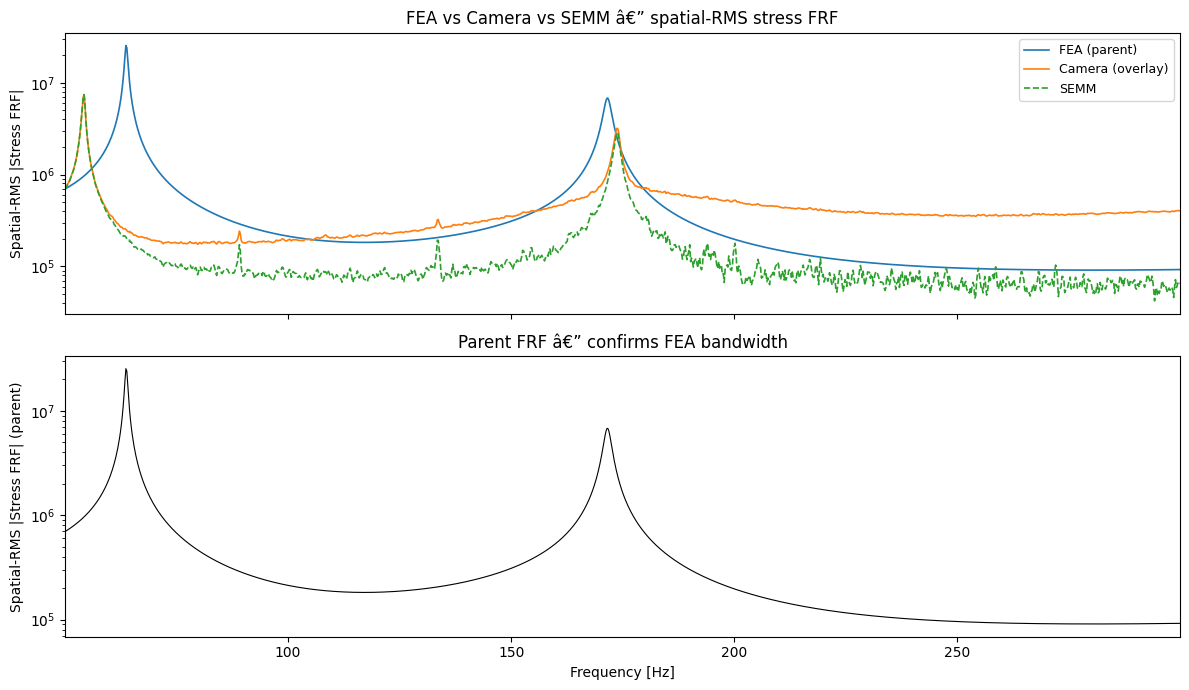

In [18]:
# ======================== FEA STRESS FRF OVERVIEW ========================
freq_axis = np.asarray(pipe.state['stage1']['freqs'], dtype=float)
Y_final2 = np.asarray(pipe.state['stage1']['Y_final2'])
Y_camera = np.asarray(pipe.state['stage1']['Y_camera'])
Y_SEMM = np.asarray(pipe.state['stage1']['Y_SEMM'])
COMPONENT_OVERLAY = int(pipe.state['stage1']['component_overlay'])

# Spatial-RMS: numerical (SX+SY component) vs camera-mapped
num_rms = np.sqrt(np.mean(np.abs(Y_final2[:, COMPONENT_OVERLAY::4, :]) ** 2, axis=(1, 2)))
cam_rms = np.sqrt(np.mean(np.abs(Y_camera) ** 2, axis=(1, 2)))
semm_rms = np.sqrt(np.mean(np.abs(Y_SEMM[:, COMPONENT_OVERLAY::4, :]) ** 2, axis=(1, 2)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.semilogy(freq_axis, np.maximum(num_rms, 1e-30), label='FEA (parent)', lw=1.2)
ax1.semilogy(freq_axis, np.maximum(cam_rms, 1e-30), label='Camera (overlay)', lw=1.2)
ax1.semilogy(freq_axis, np.maximum(semm_rms, 1e-30), label='SEMM', lw=1.2, ls='--')
ax1.set_ylabel('Spatial-RMS |Stress FRF|')
ax1.set_title('FEA vs Camera vs SEMM â€” spatial-RMS stress FRF')
ax1.legend(fontsize=9)

# Force spectrum quality (if available from camera FRFs)
ax2.semilogy(freq_axis, np.maximum(num_rms, 1e-30), 'k-', lw=0.8)
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Spatial-RMS |Stress FRF| (parent)')
ax2.set_title('Parent FRF â€” confirms FEA bandwidth')

ax1.set_xlim(freq_axis[0], freq_axis[-1])
plt.tight_layout()
plt.show()

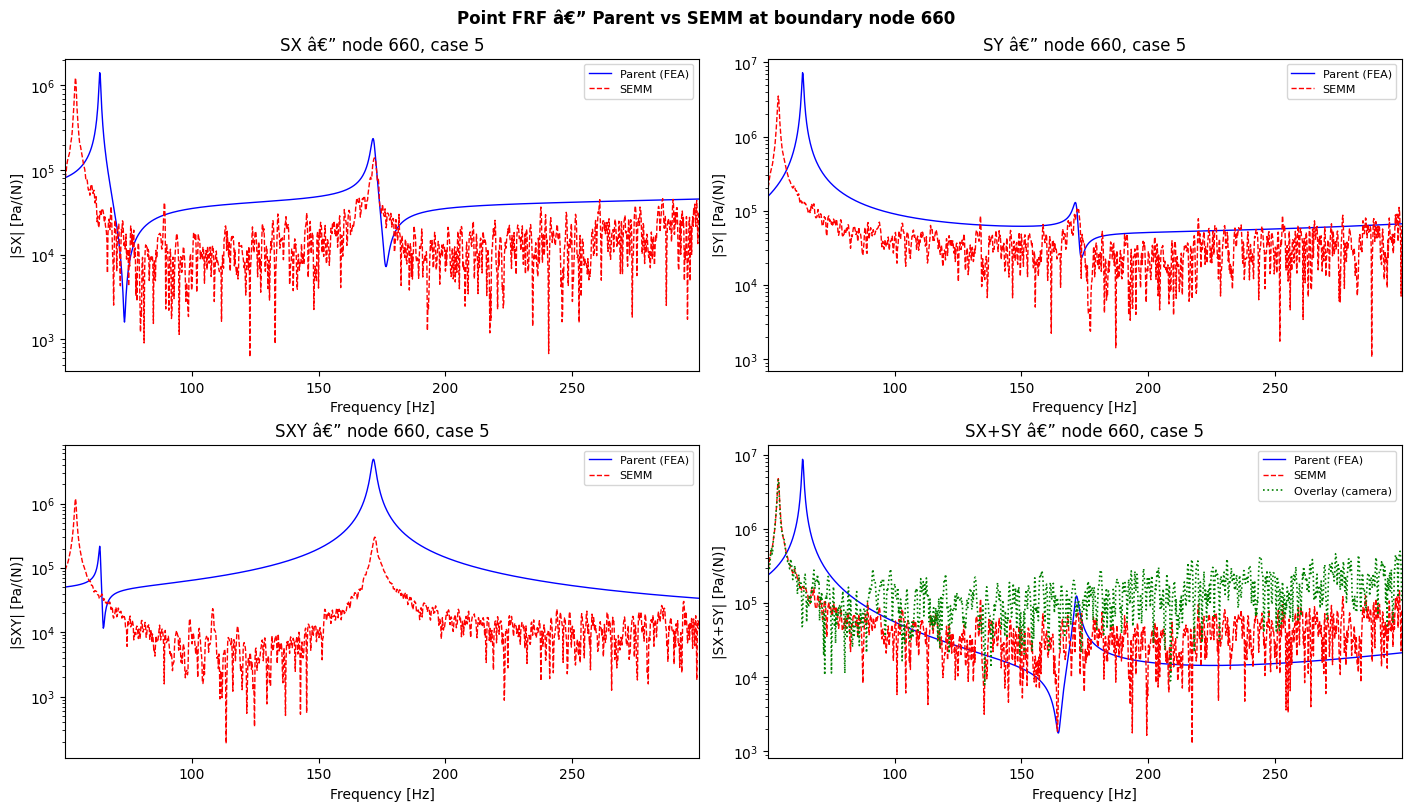

In [19]:
# ======================== PARENT / OVERLAY / SEMM â€” POINT FRF ========================
node_coords = np.asarray(pipe.state['stage1']['node_coords'], dtype=float)
b_nodes = np.asarray(pipe.state['stage1']['b_nodes'], dtype=int)
Y_overlay_num = np.asarray(pipe.state['stage1']['Y_overlay_num'])

# Select a boundary node near the center of the plate
plate_cx = (node_coords[:, 0].min() + node_coords[:, 0].max()) / 2
plate_cy = (node_coords[:, 1].min() + node_coords[:, 1].max()) / 2
dist_center = np.sqrt((node_coords[b_nodes, 0] - plate_cx)**2 +
                       (node_coords[b_nodes, 1] - plate_cy)**2)
i_nearest = np.argmin(dist_center)
node_idx = b_nodes[i_nearest]

# Choose a case to plot (use last case for variety)
CASE_IDX = min(5, Y_SEMM.shape[2] - 1)

comp_labels = ['SX', 'SY', 'SXY', 'SX+SY']
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

for ic, (ax, clabel) in enumerate(zip(axes.flat, comp_labels)):
    dof = node_idx * 4 + ic
    parent = Y_final2[:, dof, CASE_IDX]
    semm = Y_SEMM[:, dof, CASE_IDX]

    ax.semilogy(freq_axis, np.maximum(np.abs(parent), 1e-30), 'b-', lw=1, label='Parent (FEA)')
    ax.semilogy(freq_axis, np.maximum(np.abs(semm), 1e-30), 'r--', lw=1, label='SEMM')

    # Overlay only available for the overlay component
    if ic == COMPONENT_OVERLAY and i_nearest < Y_overlay_num.shape[1]:
        overlay = Y_overlay_num[:, i_nearest, CASE_IDX]
        ax.semilogy(freq_axis, np.maximum(np.abs(overlay), 1e-30), 'g:', lw=1.2, label='Overlay (camera)')

    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel(f'|{clabel}| [Pa/(N)]')
    ax.set_title(f'{clabel} â€” node {node_idx}, case {CASE_IDX}')
    ax.legend(fontsize=8)
    ax.set_xlim(freq_axis[0], freq_axis[-1])

fig.suptitle(f'Point FRF â€” Parent vs SEMM at boundary node {node_idx}', fontsize=12, fontweight='bold')
plt.show()

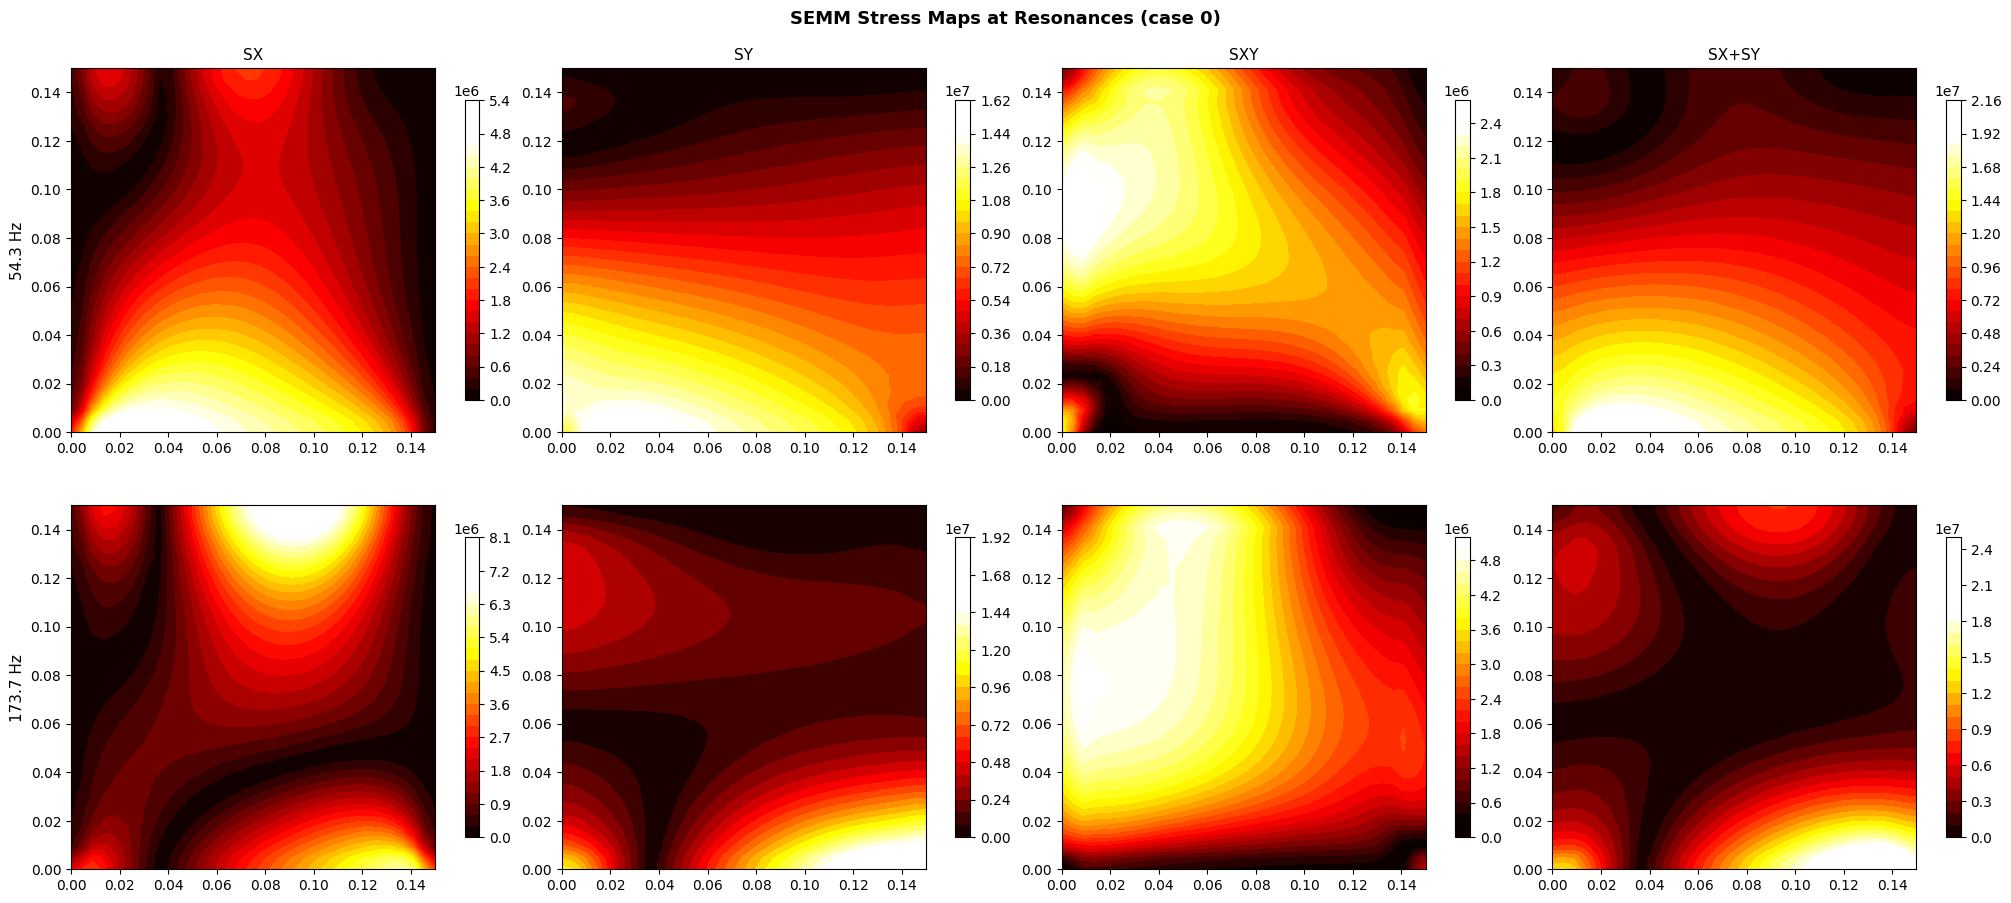

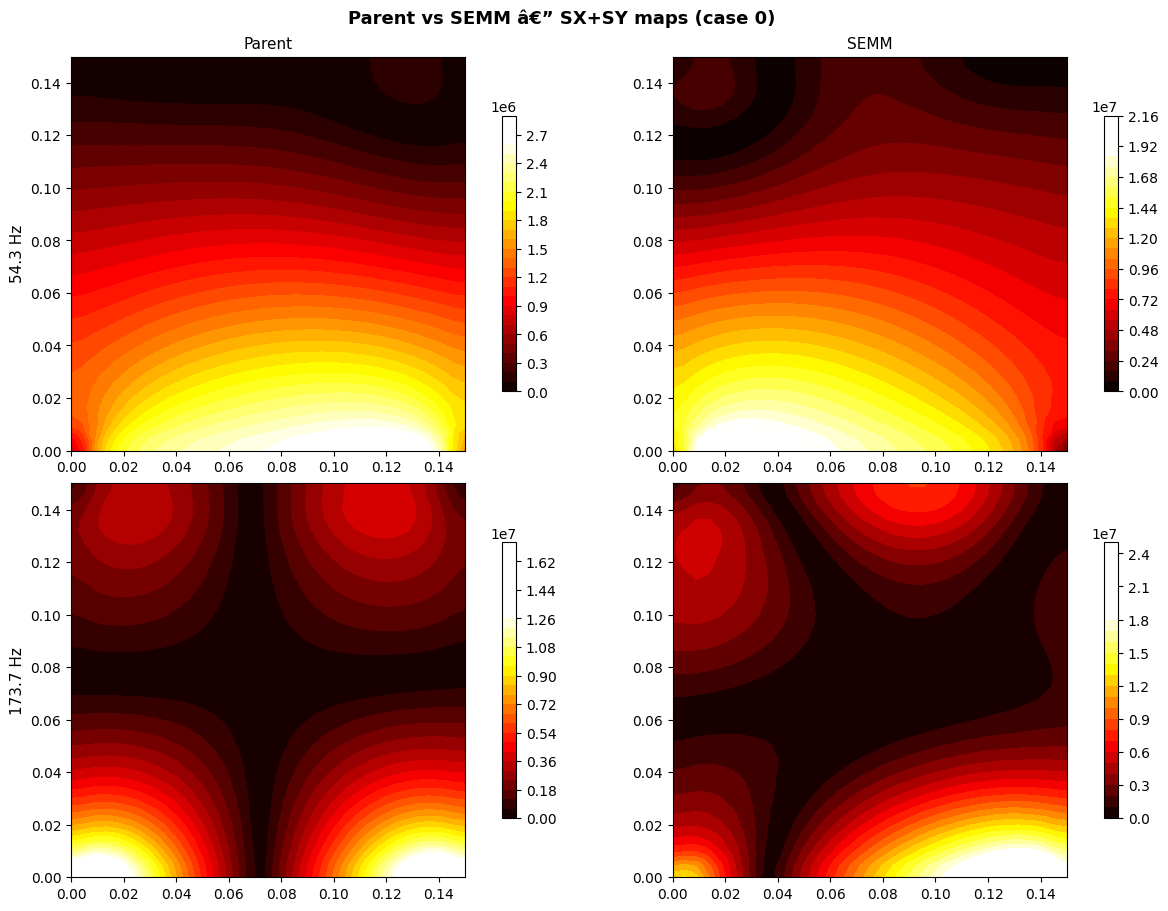


Stress peaks used for maps:
  54.32 Hz
  173.74 Hz


In [20]:
# ======================== STRESS MAPS AT RESONANCES ========================
# Find top resonance peaks from spatial-RMS of SEMM stress
semm_metric = np.sqrt(np.mean(np.abs(Y_SEMM[:, COMPONENT_OVERLAY::4, :]) ** 2, axis=(1, 2)))
peak_stress_idx, _ = find_peaks(semm_metric, height=np.max(semm_metric) * 0.1, distance=5)

# Sort by amplitude, take top 3
if len(peak_stress_idx) > 0:
    amp_order = np.argsort(semm_metric[peak_stress_idx])[::-1]
    peak_stress_idx = peak_stress_idx[amp_order[:min(3, len(amp_order))]]
    peak_stress_idx = np.sort(peak_stress_idx)  # re-sort by frequency

n_peaks = len(peak_stress_idx)
if n_peaks == 0:
    print('No stress peaks detected.')
else:
    # Use the first available case for spatial maps
    MAP_CASE = 0
    comp_names = ['SX', 'SY', 'SXY', 'SX+SY']
    n_nodes = node_coords.shape[0]
    tri = mtri.Triangulation(node_coords[:, 0], node_coords[:, 1])

    fig, axes = plt.subplots(n_peaks, 4, figsize=(20, 4.5 * n_peaks), constrained_layout=True)
    if n_peaks == 1:
        axes = axes[np.newaxis, :]

    sources = [
        ('Parent', Y_final2),
        ('SEMM', Y_SEMM),
    ]

    for r, fi in enumerate(peak_stress_idx):
        f_hz = freq_axis[fi]
        for ic, cname in enumerate(comp_names):
            ax = axes[r, ic]
            # Show SEMM stress map
            vals = np.abs(Y_SEMM[fi, ic::4, MAP_CASE])
            vmin, vmax = np.percentile(vals, [2, 98])
            tcf = ax.tricontourf(tri, vals, levels=30, cmap='hot', vmin=vmin, vmax=vmax)
            plt.colorbar(tcf, ax=ax, shrink=0.7)
            ax.set_aspect('equal')
            if r == 0:
                ax.set_title(cname, fontsize=11)
            if ic == 0:
                ax.set_ylabel(f'{f_hz:.1f} Hz', fontsize=11)

    fig.suptitle(f'SEMM Stress Maps at Resonances (case {MAP_CASE})', fontsize=13, fontweight='bold')
    plt.show()

    # Also show Parent vs SEMM comparison for the SX+SY component
    fig, axes = plt.subplots(n_peaks, 2, figsize=(12, 4.5 * n_peaks), constrained_layout=True)
    if n_peaks == 1:
        axes = axes[np.newaxis, :]

    for r, fi in enumerate(peak_stress_idx):
        f_hz = freq_axis[fi]
        for j, (src_name, src_data) in enumerate(sources):
            ax = axes[r, j]
            vals = np.abs(src_data[fi, COMPONENT_OVERLAY::4, MAP_CASE])
            vmin, vmax = np.percentile(vals, [2, 98])
            tcf = ax.tricontourf(tri, vals, levels=30, cmap='hot', vmin=vmin, vmax=vmax)
            plt.colorbar(tcf, ax=ax, shrink=0.7)
            ax.set_aspect('equal')
            if r == 0:
                ax.set_title(src_name, fontsize=11)
            if j == 0:
                ax.set_ylabel(f'{f_hz:.1f} Hz', fontsize=11)

    fig.suptitle(f'Parent vs SEMM â€” SX+SY maps (case {MAP_CASE})', fontsize=13, fontweight='bold')
    plt.show()

    print(f'\nStress peaks used for maps:')
    for fi in peak_stress_idx:
        print(f'  {freq_axis[fi]:.2f} Hz')

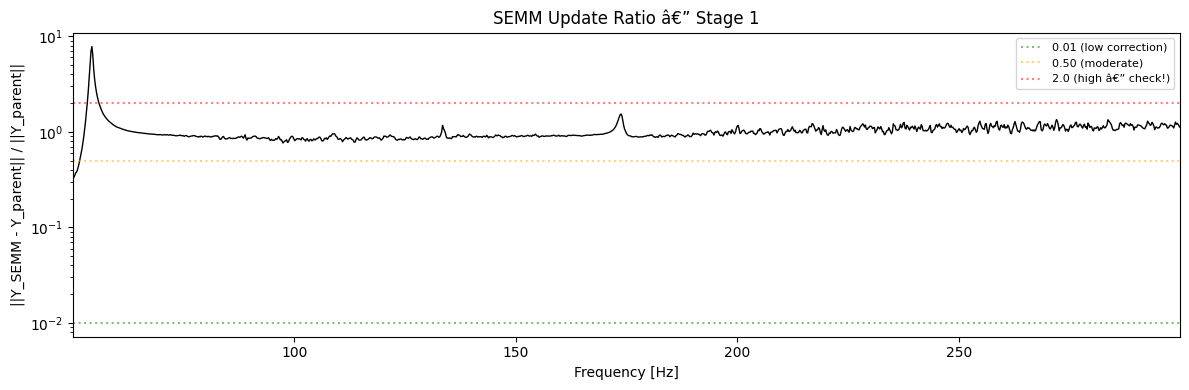

Update ratio: min=0.3285, max=7.7886, mean=1.0199, median=0.9511


In [21]:
# ======================== SEMM UPDATE RATIO ========================
# Per-frequency: ||Y_SEMM - Y_parent|| / ||Y_parent||
# Healthy range ~0.01-0.5; values >2 indicate problems
diff_norm = np.sqrt(np.sum(np.abs(Y_SEMM - Y_final2) ** 2, axis=(1, 2)))
parent_norm = np.sqrt(np.sum(np.abs(Y_final2) ** 2, axis=(1, 2)))
update_ratio = diff_norm / np.maximum(parent_norm, 1e-30)

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(freq_axis, np.maximum(update_ratio, 1e-10), 'k-', lw=1)
ax.axhline(0.01, color='g', ls=':', alpha=0.5, label='0.01 (low correction)')
ax.axhline(0.5, color='orange', ls=':', alpha=0.5, label='0.50 (moderate)')
ax.axhline(2.0, color='r', ls=':', alpha=0.5, label='2.0 (high â€” check!)')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('||Y_SEMM - Y_parent|| / ||Y_parent||')
ax.set_title('SEMM Update Ratio â€” Stage 1')
ax.legend(fontsize=8)
ax.set_xlim(freq_axis[0], freq_axis[-1])
plt.tight_layout()
plt.show()

print(f'Update ratio: min={update_ratio.min():.4f}, max={update_ratio.max():.4f}, '
      f'mean={update_ratio.mean():.4f}, median={np.median(update_ratio):.4f}')

In [23]:
# ======================== SAVE STAGE 1 ========================
from datetime import datetime

run_name = datetime.now().strftime('stage1_%Y%m%d_%H%M%S')
save_dir = pipe.save_stage1(run_name=run_name)
print(f'Saved to: {save_dir}')
print()

# List saved files
for f in sorted(save_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:30s} {size_kb:8.1f} KB')

# Also list run metadata in parent
meta_file = save_dir.parent / 'run_metadata.json'
if meta_file.exists():
    print(f'  {"run_metadata.json":30s} {meta_file.stat().st_size / 1024:8.1f} KB')

Saved to: C:\Users\jasas\Work\Clanki\Clanek_2\Trigger_and_acquisition\dual_stage_base_pipeline\outputs\stage1_20260306_075427\stage1

  freq_axis.npy                       9.7 KB
  mapping_metadata.json               0.9 KB
  node_coords.npy                    27.2 KB
  sync_info.json                      3.7 KB
  Y_cam_all.npy                  133193.0 KB
  Y_camera.npy                   133193.0 KB
  Y_final2.npy                   532771.6 KB
  Y_SEMM_stage1.npy              532771.6 KB
  run_metadata.json                   4.0 KB


In [24]:
# ======================== LOAD & VERIFY ========================
# Quick reload test â€” confirms expansion notebooks can load this
import json

Y_SEMM_check = np.load(save_dir / 'Y_SEMM_stage1.npy')
freqs_check = np.load(save_dir / 'freq_axis.npy')
coords_check = np.load(save_dir / 'node_coords.npy')

with open(save_dir / 'mapping_metadata.json') as f:
    meta_check = json.load(f)

print('Reload verification:')
print(f'  Y_SEMM:      {Y_SEMM_check.shape} {Y_SEMM_check.dtype}')
print(f'  freq_axis:   {freqs_check.shape} [{freqs_check[0]:.1f} .. {freqs_check[-1]:.1f}] Hz')
print(f'  node_coords: {coords_check.shape}')
print(f'  mapping meta keys: {sorted(meta_check.keys())}')
print()
print(f'Match original: {np.allclose(Y_SEMM_check, Y_SEMM)}')
print(f'\nTo load in expansion notebooks, set:')
print(f"  STAGE1_RUN = '{save_dir.parent.name}'")

Reload verification:
  Y_SEMM:      (1229, 4624, 6) complex128
  freq_axis:   (1229,) [50.0 .. 299.9] Hz
  node_coords: (1156, 3)
  mapping meta keys: ['case_labels', 'cols', 'component_overlay', 'diag_cam', 'max_cam_to_num_dist', 'mean_cam_to_num_dist', 'n_interface_dofs', 'rows', 'stage']

Match original: True

To load in expansion notebooks, set:
  STAGE1_RUN = 'stage1_20260306_075427'
